In [1]:
%pip install pandas numpy matplotlib pyfixest

Note: you may need to restart the kernel to use updated packages.


# Imports

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pyfixest as pf


import os

folder_path = "../output/simulations_revision_regression_convex_adj"

# Tests


In [ ]:
profits = panel.query('firm_id == 1 & year >= 300')[['K','sigma','D','profit']].drop_duplicates()
profits = profits.sort_values(by = ['K','D','sigma'])
K_vals = profits['K'].unique()
D_vals = profits['D'].unique()
S_vals = profits['sigma'].unique()

mat = (profits
       .set_index(['K','D','sigma'])['profit']
       .unstack(['D','sigma'])
       .reindex(index=K_vals,
                columns=pd.MultiIndex.from_product([D_vals, S_vals]))
       .values
       .reshape(len(K_vals), len(D_vals), len(S_vals)))


In [1]:
mat

NameError: name 'mat' is not defined

count    1.998000e+05
mean     3.496377e-02
std      1.082134e-02
min      3.233793e-07
0%       3.233793e-07
10%      2.895577e-02
20%      2.909832e-02
30%      2.916759e-02
40%      2.923108e-02
50%      2.931309e-02
60%      2.977786e-02
70%      3.517203e-02
80%      3.972480e-02
90%      5.483225e-02
max      7.577495e-02
Name: E_last_semester, dtype: float64

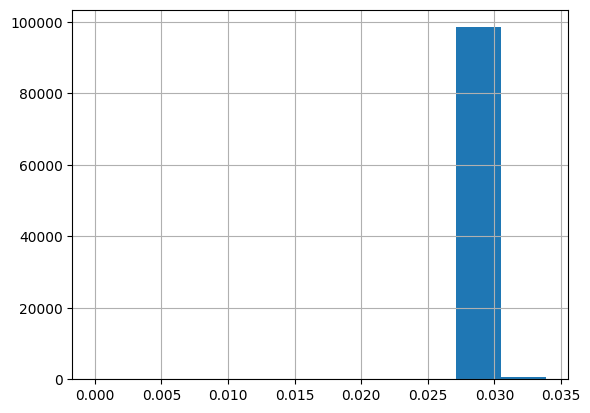

In [10]:
panel = pd.read_csv(os.path.join(folder_path,f"panel_all.csv"))
panel.query('phi == 5').E_last_semester.hist()
panel.E_last_semester.describe(np.arange(0,1,0.1))

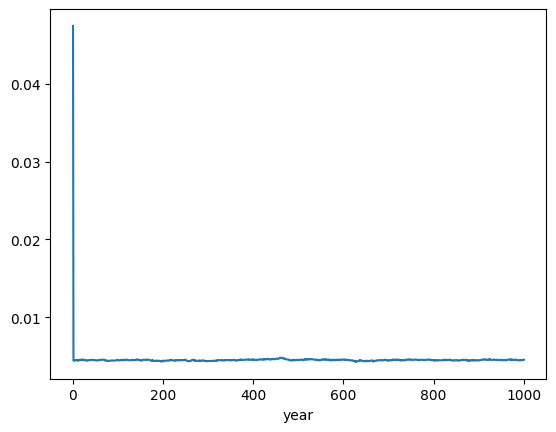

In [ ]:

test = 1 
panel = pd.read_parquet(os.path.join(folder_path,f"panel_data_s{test}1.parquet"))
panel.groupby(['year']).K.mean().plot()
panel = panel.groupby(['firm_id']).tail(700)
panel['q'] = pd.qcut(panel.D,q = 10,    labels=np.arange(1,11))
panel = panel.query('firm_id == 1')
panel['D_lag1'] = panel.groupby('firm_id')['profit'].shift(1)

panel['autocorr_1'] = panel.groupby('firm_id')['profit'].transform(
    lambda x: x.autocorr(lag=1)
)

<Axes: xlabel='year'>

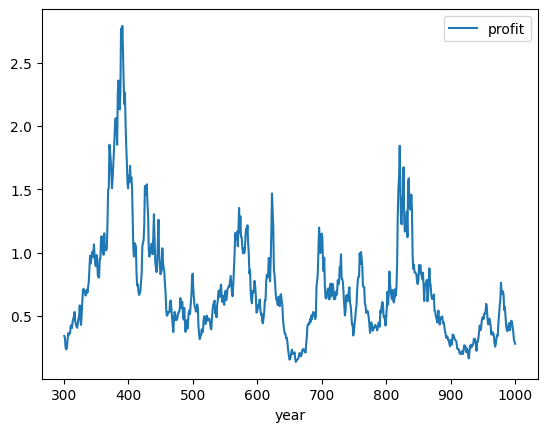

In [ ]:
panel.plot(x = "year",y = 'profit')

<Axes: xlabel='year'>

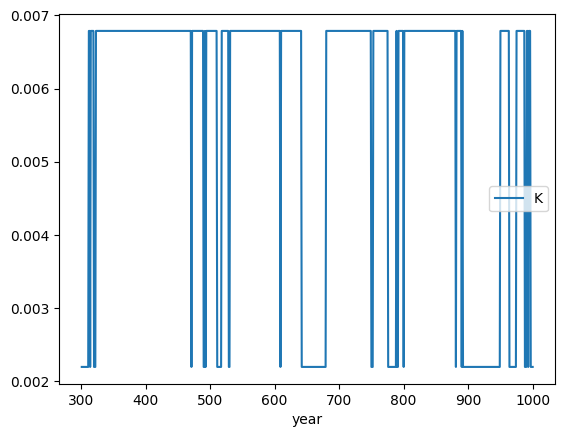

In [ ]:
panel.query('firm_id == 1').plot(x = "year",y = 'K')

In [ ]:
panel.query('firm_id == 1').head(50)

,firm_id,year,K,D,D_half,sigma,sigma_half,log_D,log_D_half,log_sigma,log_sigma_half,I,Delta_I,I_total,I_rate,profit,E_last_semester,E_beginning,E_half
300,1,301,1.801827,479.256305,413.334165,0.102551,0.093792,6.172236,6.024256,-2.277399,-2.366677,0.189929,0.0,0.189929,0.105409,0.612475,0.189929,0.189929,0.189929
301,1,302,1.801827,513.539680,420.683309,0.091228,0.117113,6.241327,6.041880,-2.394388,-2.144616,0.189929,0.0,0.189929,0.105409,0.638026,0.189929,0.189929,0.189929
302,1,303,1.801827,380.139843,403.706233,0.115482,0.104338,5.940539,6.000687,-2.158642,-2.260123,0.189929,0.0,0.189929,0.105409,0.544937,0.189929,0.189929,0.189929
303,1,304,1.801827,462.825553,410.026966,0.098588,0.093141,6.137350,6.016223,-2.316805,-2.373637,0.189929,0.0,0.189929,0.105409,0.600308,0.189929,0.189929,0.189929
304,1,305,1.801827,472.568972,542.165265,0.091839,0.083495,6.158184,6.295571,-2.387720,-2.482972,0.189929,0.0,0.189929,0.105409,0.687517,0.189929,0.189929,0.189929
305,1,306,1.801827,547.098658,626.660535,0.090717,0.094720,6.304629,6.440405,-2.400014,-2.356832,0.189929,0.0,0.189929,0.105409,0.783874,0.189929,0.189929,0.189929
306,1,307,1.801827,601.603636,585.426779,0.098327,0.086687,6.399599,6.372341,-2.319460,-2.445456,0.189929,0.0,0.189929,0.105409,0.792010,0.189929,0.189929,0.189929
307,1,308,1.801827,522.584053,469.977619,0.091880,0.090430,6.258786,6.152685,-2.387268,-2.403174,0.189929,0.0,0.189929,0.105409,0.674025,0.189929,0.189929,0.189929
308,1,309,1.801827,498.376591,532.321508,0.086234,0.091327,6.211356,6.277248,-2.450689,-2.393308,0.189929,0.0,0.189929,0.105409,0.697366,0.189929,0.189929,0.189929
309,1,310,1.801827,482.992477,550.921074,0.111832,0.102472,6.180001,6.311592,-2.190755,-2.278167,0.189929,0.0,0.189929,0.105409,0.699225,0.189929,0.189929,0.189929


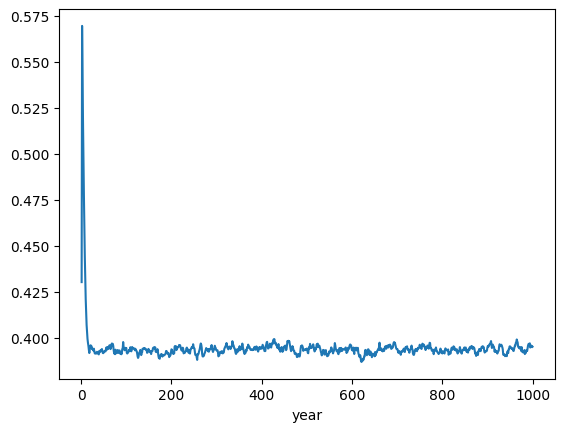

In [ ]:
test = 1 
panel = pd.read_parquet(os.path.join(folder_path,f"panel_data_s{test}1.parquet"))
panel.groupby(['year']).K.mean().plot()
panel = panel.groupby(['firm_id']).tail(700)

In [5]:
panel['Rev_0'] = np.log(panel['E_beginning'])-np.log(panel['E_last_semester'])
panel['Rev_1'] = np.log(panel['E_half'])-np.log(panel['E_beginning'])


mu_D = np.log(500)
rho_D = 0.5

panel['m_t'] = mu_D*(1-rho_D) + rho_D*panel.log_D
panel['Var_D_pred'] = (np.exp(panel.sigma**2)-1)*np.exp(2*mu_D+panel.sigma**2)/10000
panel['D_pred'] = np.exp(panel.m_t + 1/2*panel.sigma**2)
panel['Var_D_pred_1'] = panel.groupby(['firm_id']).Var_D_pred.transform("shift")

pf.feols("Rev_0 ~ Var_D_pred + D_pred + K | firm_id ",panel).summary()

###

Estimation:  OLS
Dep. var.: Rev_0, Fixed effects: firm_id
Inference:  iid
Observations:  999000

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| Var_D_pred    |     -0.014 |        0.003 |    -4.596 |      0.000 | -0.020 |  -0.008 |
| D_pred        |      0.001 |        0.000 |   242.866 |      0.000 |  0.001 |   0.001 |
| K             |     -0.332 |        0.003 |  -125.483 |      0.000 | -0.337 |  -0.326 |
---
RMSE: 0.159 R2: 0.069 R2 Within: 0.069 


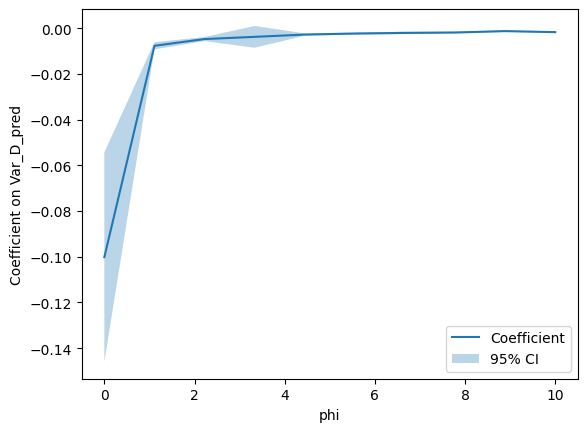

In [8]:
import numpy as np
import matplotlib.pyplot as plt

phis = np.sort(panel.phi.unique())

betas = []
ses = []

for phi in phis:
    
    model = pf.feols(
        "Rev_0 ~ Var_D_pred + D_pred + K | firm_id",
        panel.query('phi == @phi')
    )
    
    betas.append(model.coef()["Var_D_pred"])
    ses.append(model.se()["Var_D_pred"])

betas = np.array(betas)
ses = np.array(ses)

# 95% confidence interval
ci_upper = betas + 1.96 * ses
ci_lower = betas - 1.96 * ses

plt.plot(phis, betas, label="Coefficient")
plt.fill_between(phis, ci_lower, ci_upper, alpha=0.3, label="95% CI")

plt.xlabel("phi")
plt.ylabel("Coefficient on Var_D_pred")
plt.legend()
plt.show()

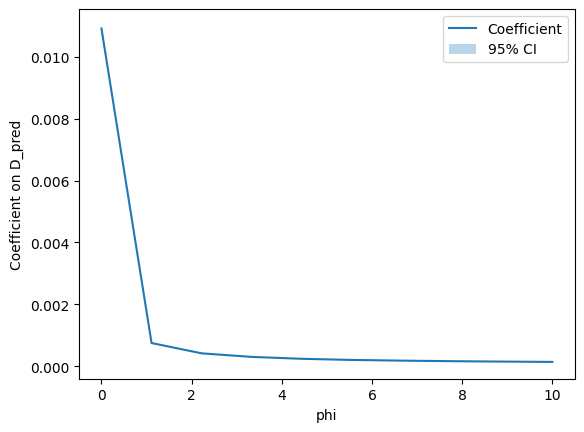

In [13]:
import numpy as np
import matplotlib.pyplot as plt

phis = np.sort(panel.phi.unique())

betas = []
ses = []

for phi in phis:
    
    model = pf.feols(
        "Rev_0 ~ Var_D_pred + D_pred + K | firm_id",
        panel.query('phi == @phi')
    )
    
    betas.append(model.coef()["D_pred"])
    ses.append(model.se()["D_pred"])

betas = np.array(betas)
ses = np.array(ses)

# 95% confidence interval
ci_upper = betas + 1.96 * ses
ci_lower = betas - 1.96 * ses

plt.plot(phis, betas, label="Coefficient")
plt.fill_between(phis, ci_lower, ci_upper, alpha=0.3, label="95% CI")

plt.xlabel("phi")
plt.ylabel("Coefficient on D_pred")
plt.legend()
plt.show()

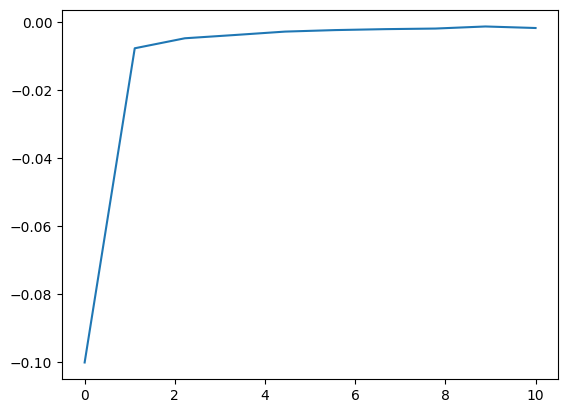

In [ ]:
sigma2 = np.exp(2 * panel['log_sigma'])

panel['var_D'] = np.exp(2 * panel['log_D'] + sigma2) * (np.exp(sigma2) - 1)